## **X Imports**


In [ ]:
# X
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import dgl
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch import nn
from dgl.nn import HeteroGraphConv, GATConv
from torch_geometric.nn import Node2Vec
from torch.nn import LayerNorm
from neo4j import GraphDatabase
import pickle
import os

import warnings
warnings.filterwarnings("ignore")

## **X Configs**

*Change Accordingly*

In [4]:
NEO_URI = "bolt://localhost:7687"
NEO_USER = "neo4j"
NEO_PASSWORD = "ABCD@1234"
CSV_PATH = "BankSim-Updated.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
SAVE_DIR = "artifacts-final"
BATCH = 5000
os.makedirs(SAVE_DIR, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

## **X I/O Utils**

In [5]:
def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

## **Build GraphDB**

Make sure Neo4j server is running before executing this cell.
If Neo4j is not running, start it using the following command in your terminal (adjust the path as needed):

For Windows (default installation):
"C:\Program Files\Neo4j\bin\neo4j.bat" start

For Linux/macOS:
neo4j start

In [6]:
driver = GraphDatabase.driver(NEO_URI, auth=(NEO_USER, NEO_PASSWORD))

### *Create Constraint*

In [7]:
constraint_cypher = """
CREATE CONSTRAINT IF NOT EXISTS FOR (c:Customer) REQUIRE c.id IS UNIQUE;
CREATE CONSTRAINT IF NOT EXISTS FOR (m:Merchant) REQUIRE m.id IS UNIQUE;
CREATE CONSTRAINT IF NOT EXISTS FOR (t:Transaction) REQUIRE t.id IS UNIQUE;
"""

with driver.session() as session:
    for stmt in constraint_cypher.strip().split(";"):
        stmt = stmt.strip()
        if stmt:
            session.run(stmt)
            
driver.close()

### *Load Data*

In [8]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df['tx_uid'] = df.index  # Unique transaction ID

# Optional: clean quotes if CSV has quoted IDs
df['customer'] = df['customer'].str.strip("'")
df['merchant'] = df['merchant'].str.strip("'")

### *CYPHER TO LOAD INTO NEO4J*

In [9]:
cypher = """
UNWIND $rows AS r
MERGE (c:Customer {id: r.customer})
  ON CREATE SET c.age = toInteger(r.age), c.gender = r.gender
MERGE (m:Merchant {id: r.merchant})
  ON CREATE SET m.category = r.category
CREATE (t:Transaction {
    id: r.tx_uid,
    amount: toFloat(r.inr_amount),
    step: toInteger(r.step),
    fraud: toInteger(r.fraud)
})
MERGE (c)-[:MAKES]->(t)
MERGE (m)-[:RECEIVES]->(t);
"""

### *BATCH INSERT INTO GRAPH*

In [14]:
with driver.session() as session:
    for start in tqdm(range(0, len(df), BATCH), desc="Inserting data"):
        batch = df.iloc[start:start + BATCH].to_dict("records")
        session.run(cypher, rows=batch)

driver.close()
print("BankSim data loaded into Neo4j successfully!!!")


Inserting data: 100%|██████████| 119/119 [01:51<00:00,  1.07it/s]

BankSim data loaded into Neo4j successfully!!!


### *Sample Query*

In [16]:
with driver.session(database="neo4j") as session:

    # Count total nodes
    node_count = session.run("MATCH (n) RETURN count(n) AS count").single()["count"]

    # Count total relationships
    rel_count = session.run("MATCH ()-[r]->() RETURN count(r) AS count").single()["count"]

    print(f"Number of nodes: {node_count}")
    print(f"Number of relationships: {rel_count}")

    # Sample: Get transactions of a specific customer
    customer_id = "C1093826151"  # Replace with actual ID from your CSV

    transactions = session.run("""
        MATCH (c:Customer {id: $customer_id})-[:MAKES]->(t:Transaction)
        RETURN t.id AS tx_id, t.amount AS amount, t.step AS step, t.fraud AS is_fraud
        ORDER BY t.step ASC
        LIMIT 10
    """, customer_id=customer_id)

    print(f"\nTransactions for Customer {customer_id}:\n")
    for record in transactions:
        print(f"ID: {record['tx_id']}, Amount: {record['amount']}, Step: {record['step']}, Fraud: {record['is_fraud']}")

driver.close()

Number of nodes: 598805
Number of relationships: 1189286

Transactions for Customer C1093826151:

ID: 0, Amount: 451.81, Step: 0, Fraud: 0
ID: 2497, Amount: 1427.93, Step: 1, Fraud: 0
ID: 5076, Amount: 3694.95, Step: 2, Fraud: 0
ID: 8664, Amount: 3140.86, Step: 3, Fraud: 0
ID: 9936, Amount: 3560.9, Step: 4, Fraud: 0
ID: 13245, Amount: 43.69, Step: 5, Fraud: 0
ID: 15042, Amount: 3930.29, Step: 6, Fraud: 0
ID: 19937, Amount: 3181.57, Step: 7, Fraud: 0
ID: 22099, Amount: 2792.32, Step: 8, Fraud: 0
ID: 22941, Amount: 1243.24, Step: 9, Fraud: 0


## **Load & Feature Engineering**

In [17]:
driver = GraphDatabase.driver(NEO_URI, auth=(NEO_USER, NEO_PASSWORD))
query = """
MATCH (c:Customer)-[:MAKES]->(t:Transaction)<-[:RECEIVES]-(m:Merchant)
RETURN c.id AS customer, m.id AS merchant, t.id AS tx_id,
        toFloat(t.amount) AS amount, toInteger(t.fraud) AS fraud
"""
with driver.session(database="neo4j") as s:
    df = pd.DataFrame(s.run(query).data())
driver.close()

# --- Feature stats ---
cust_stats = df.groupby("customer").agg(
    cust_txn_count=("tx_id", "count"),
    cust_avg_amount=("amount", "mean")
).fillna(0)

merch_stats = df.groupby("merchant").agg(
    merch_txn_count=("tx_id", "count"),
    merch_avg_amount=("amount", "mean"),
    merch_fraud_rate=("fraud", "mean")
).fillna(0)

customers = df.customer.unique()
merchants = df.merchant.unique()
cust2id = {c: i for i, c in enumerate(customers)}
merch2id = {m: i for i, m in enumerate(merchants)}
save_pickle(cust2id, f"{SAVE_DIR}/cust2id.pkl")
save_pickle(merch2id, f"{SAVE_DIR}/merch2id.pkl")

try:
    src_c = torch.tensor(df.customer.map(cust2id).values.astype(np.int64), dtype=torch.int64)
    dst_t = torch.tensor(df.index.values.astype(np.int64), dtype=torch.int64)
    src_m = torch.tensor(df.merchant.map(merch2id).values.astype(np.int64), dtype=torch.int64)
    
    print(f"Tensor shapes: src_c={src_c.shape}, dst_t={dst_t.shape}, src_m={src_m.shape}")
    print(f"Tensor dtypes: src_c={src_c.dtype}, dst_t={dst_t.dtype}, src_m={src_m.dtype}")
    
except Exception as e:
    print(f"Error creating tensors: {e}")
    print("Debugging info:")
    print(f"Customer mapping has NaN: {df.customer.map(cust2id).isna().sum()}")
    print(f"Merchant mapping has NaN: {df.merchant.map(merch2id).isna().sum()}")

graph_data = {
    ("customer", "MAKES", "transaction"): (src_c, dst_t),
    ("merchant", "RECEIVES", "transaction"): (src_m, dst_t),
    ("transaction", "MAKES_BY", "customer"): (dst_t, src_c),
    ("transaction", "RECEIVES_BY", "merchant"): (dst_t, src_m)
}

g = dgl.heterograph(graph_data)

Tensor shapes: src_c=torch.Size([594643]), dst_t=torch.Size([594643]), src_m=torch.Size([594643])
Tensor dtypes: src_c=torch.int64, dst_t=torch.int64, src_m=torch.int64


## **Nodde2Vec Embedding**

In [18]:
def node2vec_embed_bipartite(g, ntype, dim=16, walk_len=5):
    # Convert to homogeneous graph
    hg = dgl.to_homogeneous(g)
    # Convert DGL graph to edge index for torch_geometric
    src, dst = hg.edges()
    edge_index = torch.stack([src, dst], dim=0).to(DEVICE)  # <-- Move to DEVICE
    num_nodes = hg.num_nodes()
    # Get node type IDs for all nodes
    ntype_ids = hg.ndata[dgl.NTYPE]
    ntype_id = g.get_ntype_id(ntype)
    node_indices = (ntype_ids == ntype_id).nonzero(as_tuple=True)[0]
    # Train Node2Vec on the homogeneous graph
    model = Node2Vec(
        edge_index, 
        embedding_dim=dim, 
        walk_length=walk_len, 
        context_size=walk_len, 
        walks_per_node=5, 
        num_nodes=num_nodes, 
        sparse=True
    ).to(DEVICE)
    optimizer = torch.optim.SparseAdam(model.parameters(), lr=0.005)
    model.train()
    for _ in range(100):
        pos_rw, neg_rw = model.sample(128)
        loss = model.loss(pos_rw, neg_rw)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Return embeddings for only the requested node type
    return model.embedding.weight.detach().cpu()[node_indices]

## **Feature Scaling**

In [19]:
scaler_tx = StandardScaler()
tx_feat = scaler_tx.fit_transform(df[["amount"]])
g.nodes["transaction"].data["x"] = torch.tensor(tx_feat, dtype=torch.float32)
g.nodes["transaction"].data["label"] = torch.tensor(df.fraud.values, dtype=torch.long)
save_pickle(scaler_tx, f"{SAVE_DIR}/tx_scaler.pkl")

mask = torch.rand(len(df))
g.nodes["transaction"].data["train_mask"] = mask < 0.7
g.nodes["transaction"].data["val_mask"] = (mask >= 0.7) & (mask < 0.85)
g.nodes["transaction"].data["test_mask"] = mask >= 0.85

scaler_cust = StandardScaler().fit(cust_stats.reindex(customers).fillna(0).values)
cust_feat = torch.tensor(scaler_cust.transform(cust_stats.reindex(customers).fillna(0).values), dtype=torch.float32)
save_pickle(scaler_cust, f"{SAVE_DIR}/cust_scaler.pkl")
g.nodes["customer"].data["x"] = cust_feat

scaler_merch = StandardScaler().fit(merch_stats.reindex(merchants).fillna(0).values)
merch_feat = torch.tensor(scaler_merch.transform(merch_stats.reindex(merchants).fillna(0).values), dtype=torch.float32)
save_pickle(scaler_merch, f"{SAVE_DIR}/merch_scaler.pkl")
g.nodes["merchant"].data["x"] = merch_feat

# # Scale statistical features
# cust_stats_arr = cust_stats.reindex(customers).fillna(0).values
# merch_stats_arr = merch_stats.reindex(merchants).fillna(0).values

# scaler_cust = StandardScaler().fit(cust_stats_arr)
# scaler_merch = StandardScaler().fit(merch_stats_arr)
# save_pickle(scaler_cust, f"{SAVE_DIR}/cust_scaler.pkl")
# save_pickle(scaler_merch, f"{SAVE_DIR}/merch_scaler.pkl")

# cust_feat = torch.tensor(scaler_cust.transform(cust_stats_arr), dtype=torch.float32)
# merch_feat = torch.tensor(scaler_merch.transform(merch_stats_arr), dtype=torch.float32)

# # --- Node2Vec Embedding ---
# cust_emb = node2vec_embed_bipartite(g, 'customer', dim=16, walk_len=5)
# merch_emb = node2vec_embed_bipartite(g, 'merchant', dim=16, walk_len=5)

# # --- Concatenate statistical + structural features ---
# cust_feat = torch.cat([cust_feat, cust_emb], dim=1)
# merch_feat = torch.cat([merch_feat, merch_emb], dim=1)

# g.nodes["customer"].data["x"] = cust_feat
# g.nodes["merchant"].data["x"] = merch_feat

## **X Model**

In [20]:
class FraudGNN(nn.Module):
    def __init__(self, in_dims, hidden_dim=64, num_heads=2, num_layers=3, dropout=0.2):
        super().__init__()
        self.in_dims = in_dims
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.dropout = nn.Dropout(dropout)

        self.input_proj = nn.ModuleDict({
            ntype: nn.Linear(in_dim, hidden_dim)
            for ntype, in_dim in in_dims.items()
        })

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(HeteroGraphConv({
                etype: GATConv(hidden_dim, hidden_dim // num_heads, num_heads)
                for etype in [('customer', 'MAKES', 'transaction'),
                              ('merchant', 'RECEIVES', 'transaction'),
                              ('transaction', 'MAKES_BY', 'customer'),
                              ('transaction', 'RECEIVES_BY', 'merchant')]
            }, aggregate='mean'))
            self.norms.append(nn.ModuleDict({
                ntype: LayerNorm(hidden_dim)
                for ntype in ['customer', 'merchant', 'transaction']
            }))

        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, g, inputs):
        h = {ntype: torch.relu(self.input_proj[ntype](feat))
             for ntype, feat in inputs.items()}

        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(g, h)
            # Flatten GAT output if needed
            for ntype in h_new:
                if h_new[ntype].dim() == 3:
                    h_new[ntype] = h_new[ntype].reshape(h_new[ntype].shape[0], -1)
            h = {
                ntype: norm[ntype](torch.relu(h_new[ntype] + h[ntype]))  # residual + norm
                for ntype in h
            }
            h = {k: self.dropout(v) for k, v in h.items()}

        return self.classifier(h["transaction"])


## **Training**

In [22]:
in_dims = {
    "customer": g.nodes["customer"].data["x"].shape[1],
    "merchant": g.nodes["merchant"].data["x"].shape[1],
    "transaction": g.nodes["transaction"].data["x"].shape[1]
}
model = FraudGNN(in_dims, hidden_dim=64, num_heads=2, num_layers=3).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

x_dict = {
    "customer": g.nodes["customer"].data["x"].to(DEVICE),
    "merchant": g.nodes["merchant"].data["x"].to(DEVICE),
    "transaction": g.nodes["transaction"].data["x"].to(DEVICE)
}
label = g.nodes["transaction"].data["label"].to(DEVICE)
train_mask = g.nodes["transaction"].data["train_mask"].to(DEVICE)
val_mask = g.nodes["transaction"].data["val_mask"].to(DEVICE)

g = g.to(DEVICE)

val_auc_list = []
best_val_auc = 0
patience = 14
counter = 0
best_model_state = None

for epoch in range(151):
    model.train()
    logits = model(g, x_dict)
    loss = loss_fn(logits[train_mask], label[train_mask])
    opt.zero_grad()
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        val_logits = logits[val_mask]
        val_labels = label[val_mask]
        val_probs = torch.softmax(val_logits, 1)[:, 1].cpu().numpy()
        val_auc = roc_auc_score(val_labels.cpu(), val_probs)
        val_auc_list.append(val_auc)
        print(f"Epoch {epoch:02d} | Val AUC: {val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict()
            counter = 0  # reset patience counter
        else:
            counter += 1
            if counter > patience:
                print(f"Early stopping triggered at epoch {epoch}. Best Val AUC: {best_val_auc:.4f}")
                break

Epoch 00 | Val AUC: 0.7202
Epoch 01 | Val AUC: 0.8376
Epoch 02 | Val AUC: 0.9042
Epoch 03 | Val AUC: 0.9345
Epoch 04 | Val AUC: 0.9328
Epoch 05 | Val AUC: 0.9480
Epoch 06 | Val AUC: 0.9655
Epoch 07 | Val AUC: 0.9706
Epoch 08 | Val AUC: 0.9676
Epoch 09 | Val AUC: 0.9771
Epoch 10 | Val AUC: 0.9758
Epoch 11 | Val AUC: 0.9776
Epoch 12 | Val AUC: 0.9745
Epoch 13 | Val AUC: 0.9737
Epoch 14 | Val AUC: 0.9824
Epoch 15 | Val AUC: 0.9837
Epoch 16 | Val AUC: 0.9827
Epoch 17 | Val AUC: 0.9808
Epoch 18 | Val AUC: 0.9829
Epoch 19 | Val AUC: 0.9840
Epoch 20 | Val AUC: 0.9839
Epoch 21 | Val AUC: 0.9845
Epoch 22 | Val AUC: 0.9878
Epoch 23 | Val AUC: 0.9874
Epoch 24 | Val AUC: 0.9847
Epoch 25 | Val AUC: 0.9861
Epoch 26 | Val AUC: 0.9874
Epoch 27 | Val AUC: 0.9837
Epoch 28 | Val AUC: 0.9869
Epoch 29 | Val AUC: 0.9879
Epoch 30 | Val AUC: 0.9887
Epoch 31 | Val AUC: 0.9900
Epoch 32 | Val AUC: 0.9883
Epoch 33 | Val AUC: 0.9903
Epoch 34 | Val AUC: 0.9910
Epoch 35 | Val AUC: 0.9900
Epoch 36 | Val AUC: 0.9885
E

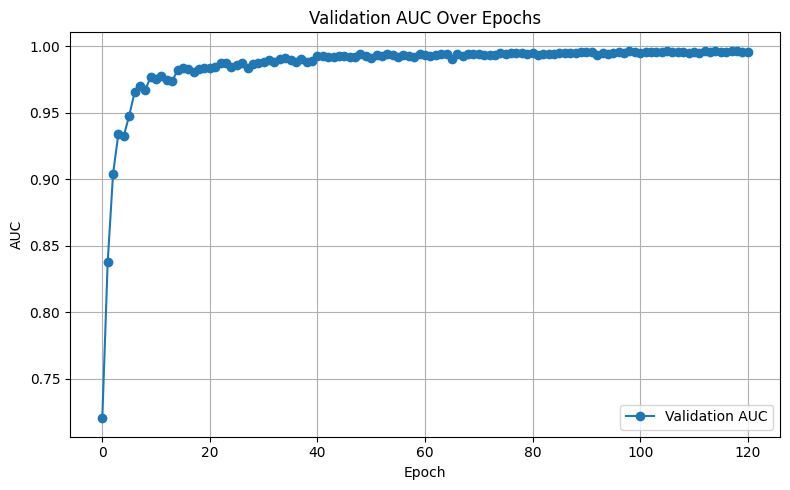

Validation AUC plot saved to val_auc_plot.png


In [23]:
plt.figure(figsize=(8, 5))
plt.plot(val_auc_list, marker='o', label='Validation AUC')
plt.title("Validation AUC Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/val_auc_plot.png")
plt.show()
print("Validation AUC plot saved to val_auc_plot.png")


## **Testing**

In [25]:
test_mask = g.nodes["transaction"].data["test_mask"].to(DEVICE)

model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    test_logits = model(g, x_dict)[test_mask]
    test_labels = label[test_mask]
    test_probs = torch.softmax(test_logits, dim=1)[:, 1].cpu().numpy()
    test_preds = test_logits.argmax(dim=1).cpu().numpy()
    test_labels_np = test_labels.cpu().numpy()

    test_auc = roc_auc_score(test_labels_np, test_probs)
    test_acc = accuracy_score(test_labels_np, test_preds)
    test_prec = precision_score(test_labels_np, test_preds)
    test_rec = recall_score(test_labels_np, test_preds)
    test_f1 = f1_score(test_labels_np, test_preds)

    print("\nFinal Test Evaluation Metrics:")
    print(f"Test AUC      : {test_auc:.4f}")
    print(f"Accuracy      : {test_acc:.4f}")
    print(f"Precision     : {test_prec:.4f}")
    print(f"Recall        : {test_rec:.4f}")
    print(f"F1 Score      : {test_f1:.4f}")


Final Test Evaluation Metrics:
Test AUC      : 0.9981
Accuracy      : 0.9958
Precision     : 0.8545
Recall        : 0.7819
F1 Score      : 0.8166


## **Store Model & Global Fallback Values**

In [26]:
global_fallbacks = {
    "cust_txn_count": float(cust_stats["cust_txn_count"].mean()),
    "cust_avg_amount": float(cust_stats["cust_avg_amount"].mean()),
    "merch_txn_count": float(merch_stats["merch_txn_count"].mean()),
    "merch_avg_amount": float(merch_stats["merch_avg_amount"].mean()),
    "merch_fraud_rate": float(merch_stats["merch_fraud_rate"].mean())
}

In [27]:
torch.save(best_model_state, f"{SAVE_DIR}/fraud_gnn.pt")
save_pickle(global_fallbacks, f"{SAVE_DIR}/global_defaults.pkl")
save_pickle(in_dims, f"{SAVE_DIR}/in_dims.pkl")

In [28]:
torch.save({
    'epoch': epoch,
    'model_state_dict': best_model_state,
    'optimizer_state_dict': opt.state_dict(),
    'best_val_auc': best_val_auc
}, f"{SAVE_DIR}/fraud_gnn_checkpoint.pt")

## **X Inference**

These things to be run earlier. Otherwise, latency will increase. That's why pre-loaded and pre-computed

In [29]:
# Load model and scalers once
cust_scaler = load_pickle(f"{SAVE_DIR}/cust_scaler.pkl")
merch_scaler = load_pickle(f"{SAVE_DIR}/merch_scaler.pkl")
tx_scaler = load_pickle(f"{SAVE_DIR}/tx_scaler.pkl")
global_defaults = load_pickle(f"{SAVE_DIR}/global_defaults.pkl")
in_dims = load_pickle(f"{SAVE_DIR}/in_dims.pkl")

model = FraudGNN(in_dims)
model.load_state_dict(torch.load(f"{SAVE_DIR}/fraud_gnn.pt", map_location=DEVICE))
model.eval().to(DEVICE)

FraudGNN(
  (dropout): Dropout(p=0.2, inplace=False)
  (input_proj): ModuleDict(
    (customer): Linear(in_features=2, out_features=64, bias=True)
    (merchant): Linear(in_features=3, out_features=64, bias=True)
    (transaction): Linear(in_features=1, out_features=64, bias=True)
  )
  (convs): ModuleList(
    (0-2): 3 x HeteroGraphConv(
      (mods): ModuleDict(
        (('customer', 'MAKES', 'transaction')): GATConv(
          (fc): Linear(in_features=64, out_features=64, bias=False)
          (feat_drop): Dropout(p=0.0, inplace=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (leaky_relu): LeakyReLU(negative_slope=0.2)
        )
        (('merchant', 'RECEIVES', 'transaction')): GATConv(
          (fc): Linear(in_features=64, out_features=64, bias=False)
          (feat_drop): Dropout(p=0.0, inplace=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (leaky_relu): LeakyReLU(negative_slope=0.2)
        )
        (('transaction', 'MAKES_BY', 'cu

## **X**

In [ ]:
neo_driver = GraphDatabase.driver(NEO_URI, auth=(NEO_USER, NEO_PASSWORD))

## **X Prediction Portion**

In [37]:
def predict_transaction_from_neo4j(customer_id, merchant_id, amount):
    query = """
    MATCH (c:Customer {id: $cid})-[:MAKES]->(t:Transaction)<-[:RECEIVES]-(m:Merchant {id: $mid})
    RETURN count(t) AS cust_txn_count,
           avg(t.amount) AS cust_avg_amount,
           count(*) AS merch_txn_count,
           avg(t.amount) AS merch_avg_amount,
           avg(t.fraud) AS merch_fraud_rate
    """
    with neo_driver.session() as session:
        record = session.run(query, cid=customer_id, mid=merchant_id).single()

    if record is None or record["cust_txn_count"] is None:
        print(f"Cold-start for {customer_id} or {merchant_id} — using fallback values.")
        record = global_defaults
    else:
        record = dict(record)
        for key in global_defaults:
            if record[key] is None:
                record[key] = global_defaults[key]

    cust_feat_raw = np.array([[record["cust_txn_count"], record["cust_avg_amount"]]], dtype=np.float32)
    merch_feat_raw = np.array([[record["merch_txn_count"], record["merch_avg_amount"], record["merch_fraud_rate"]]], dtype=np.float32)
    tx_feat_raw = np.array([[amount]], dtype=np.float32)

    # Create a new heterogeneous graph directly
    g = dgl.heterograph({
        ("customer", "MAKES", "transaction"): ([0], [0]),
        ("merchant", "RECEIVES", "transaction"): ([0], [0]),
        ("transaction", "MAKES_BY", "customer"): ([0], [0]),
        ("transaction", "RECEIVES_BY", "merchant"): ([0], [0])
    })
    
    g.nodes["customer"].data["x"] = torch.tensor(cust_scaler.transform(cust_feat_raw), dtype=torch.float32)
    g.nodes["merchant"].data["x"] = torch.tensor(merch_scaler.transform(merch_feat_raw), dtype=torch.float32)
    g.nodes["transaction"].data["x"] = torch.tensor(tx_scaler.transform(tx_feat_raw), dtype=torch.float32)

    g = g.to(DEVICE)
    x_dict = {ntype: g.nodes[ntype].data["x"] for ntype in g.ntypes}

    with torch.no_grad():
        logits = model(g, x_dict)
        prob = torch.softmax(logits, dim=1)[0][1].item()
        print(f"Real-Time Fraud Probability: {prob:.4f}")
        return prob


In [48]:
predict_transaction_from_neo4j("C1865204568", "HALLOOM2687", 69999999)

Real-Time Fraud Probability: 0.9399


0.9399271011352539